In [1]:
# --- Step 1: Install Required Packages ---
!pip install pyspellchecker tensorflow imbalanced-learn

# --- Step 2: Import Libraries ---
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# import contractions
from spellchecker import SpellChecker

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE
import joblib

In [2]:
# Load the dataset
file_path = '/Users/vaishnavi.bande/Desktop/DA_Indi/Tweets.csv'
df = pd.read_csv(file_path)

# Display the first 5 rows
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

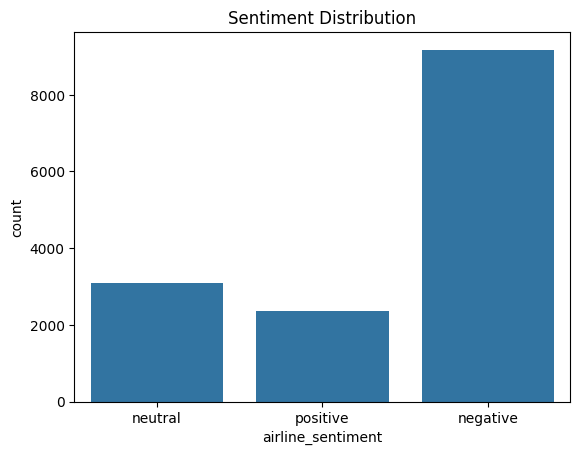

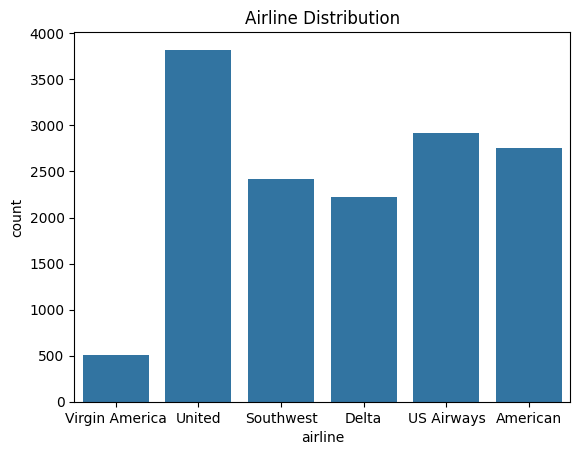

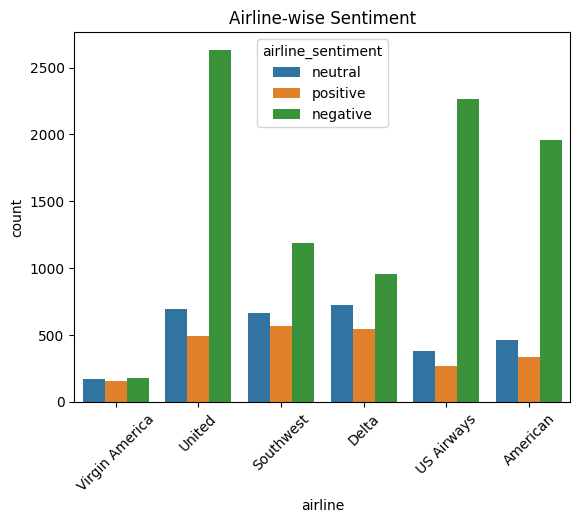

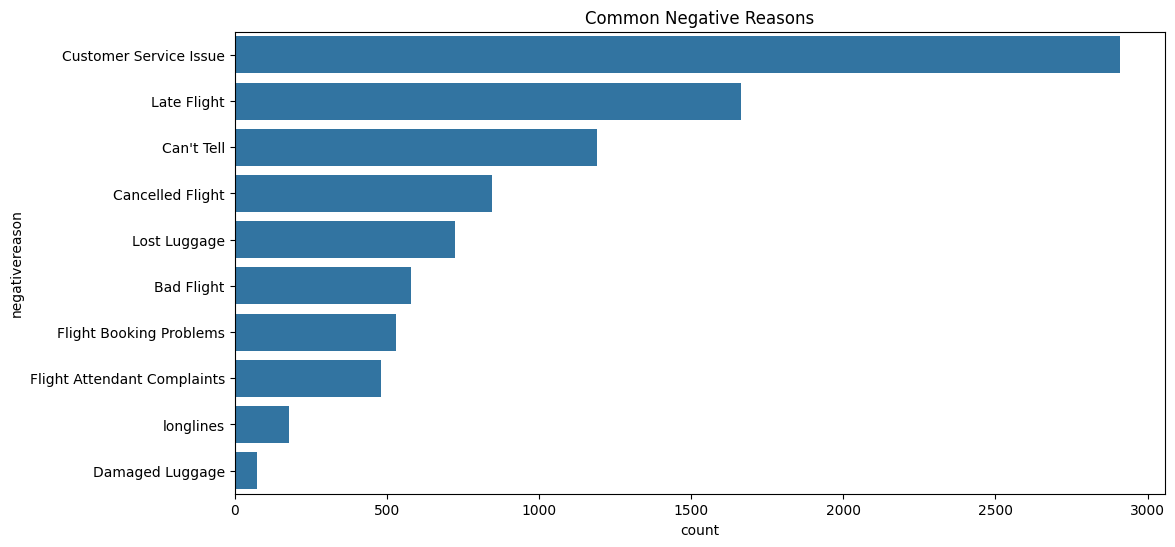

In [3]:
# --- Step 4: EDA and Visualization ---
print(df.info())
print(df.isnull().sum())
print(df['airline_sentiment'].value_counts())
sns.countplot(x='airline_sentiment', data=df)
plt.title('Sentiment Distribution')
plt.show()

sns.countplot(x='airline', data=df)
plt.title('Airline Distribution')
plt.show()

sns.countplot(x='airline', hue='airline_sentiment', data=df)
plt.title('Airline-wise Sentiment')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12,6))
sns.countplot(y='negativereason', data=df, order=df['negativereason'].value_counts().index)
plt.title('Common Negative Reasons')
plt.show()

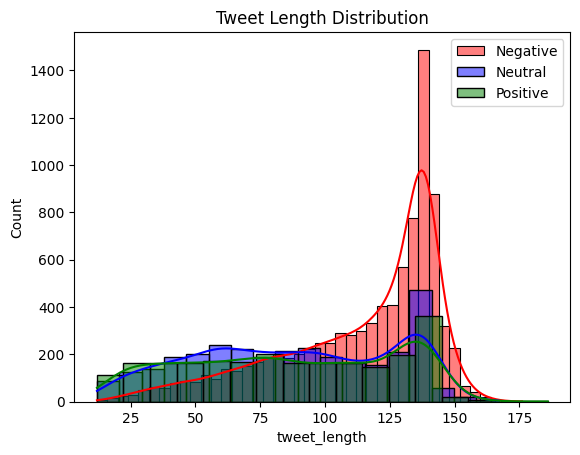

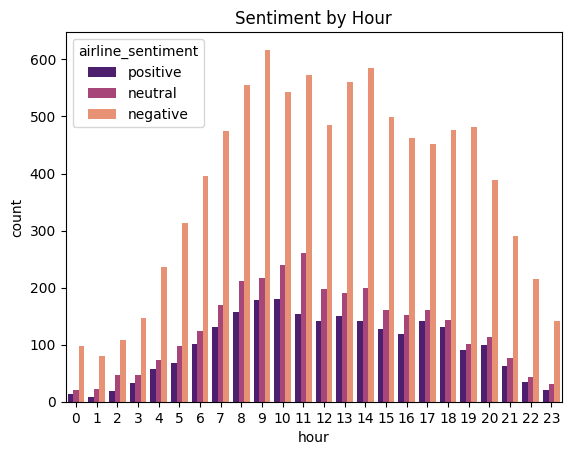

In [4]:
# --- Step 5: Time and Length Based Features ---
df['tweet_created'] = pd.to_datetime(df['tweet_created'])
df['hour'] = df['tweet_created'].dt.hour
df['tweet_length'] = df['text'].apply(len)

sns.histplot(df[df['airline_sentiment']=='negative']['tweet_length'], color='red', kde=True, label='Negative')
sns.histplot(df[df['airline_sentiment']=='neutral']['tweet_length'], color='blue', kde=True, label='Neutral')
sns.histplot(df[df['airline_sentiment']=='positive']['tweet_length'], color='green', kde=True, label='Positive')
plt.legend()
plt.title('Tweet Length Distribution')
plt.show()

sns.countplot(x='hour', hue='airline_sentiment', data=df, palette='magma')
plt.title('Sentiment by Hour')
plt.show()

In [5]:
# --- Step 6: Handle Negativereason Gold Column ---
if 'negativereason_gold' in df.columns:
    df['negativereason'] = np.where(df['negativereason_gold'].notnull(), df['negativereason_gold'], df['negativereason'])
    df.drop(columns=['negativereason_gold'], inplace=True)

In [6]:
# --- Step 7: Preprocess Text ---
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

spell = SpellChecker()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

URL_PATTERN = re.compile(r'http\S+|www\S+|https\S+')
MENTION_HASHTAG_PATTERN = re.compile(r'@\w+|#\w+')
SPECIAL_CHAR_PATTERN = re.compile(r'[^a-zA-Z\s]')
EXTRA_SPACE_PATTERN = re.compile(r'\s+')

def clean_text(text):
    text = text.lower()
    text = URL_PATTERN.sub('', text)
    text = MENTION_HASHTAG_PATTERN.sub('', text)
    text = SPECIAL_CHAR_PATTERN.sub('', text)
    text = EXTRA_SPACE_PATTERN.sub(' ', text).strip()
    # Replacing contractions manually here, as the contractions library isn't available
    text = text.replace("can't", "cannot").replace("won't", "will not").replace("i'm", "i am")  # Add more contractions as needed
    return text

def tokenize(text):
    return text.split()

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

def lemmatize_and_correct(tokens):
    return [spell.correction(lemmatizer.lemmatize(word)) or word for word in tokens]

df['cleaned_text'] = df['text'].apply(clean_text)
df['tokens'] = df['cleaned_text'].apply(tokenize)
df['tokens'] = df['tokens'].apply(remove_stopwords)
df['tokens'] = df['tokens'].apply(lemmatize_and_correct)
df['cleaned_text_final'] = df['tokens'].str.join(' ')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/vaishnavi.bande/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/vaishnavi.bande/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/vaishnavi.bande/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [7]:
# --- Step 8: Vectorization ---
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['cleaned_text_final']).toarray()
y = df['airline_sentiment']

Distribution of sentiments before balancing
 airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


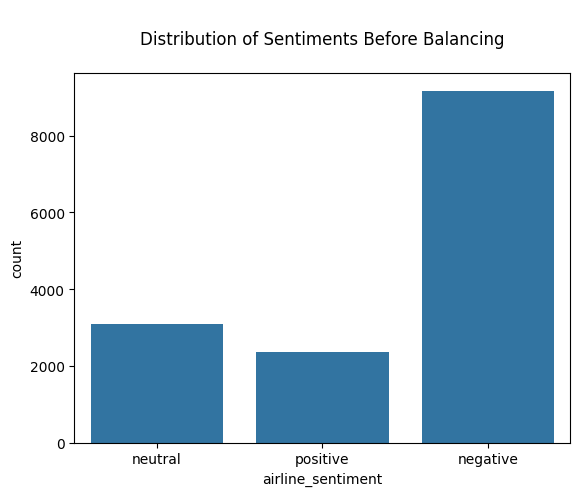


Classification Report Before Balancing:
              precision    recall  f1-score   support

    negative       0.82      0.94      0.87      1889
     neutral       0.66      0.48      0.55       580
    positive       0.81      0.61      0.70       459

    accuracy                           0.79      2928
   macro avg       0.76      0.67      0.71      2928
weighted avg       0.79      0.79      0.78      2928


Confusion Matrix:
[[1771   86   32]
 [ 272  276   32]
 [ 122   57  280]]

Accuracy Score:
0.79474043715847


In [8]:
# Check the distribution of sentiments before balancing
print('Distribution of sentiments before balancing\n', df['airline_sentiment'].value_counts())

# Plot the distribution of sentiments
sns.countplot(x='airline_sentiment', data=df)
plt.title('\nDistribution of Sentiments Before Balancing\n')
plt.show()


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split  # Importing train_test_split

# Vectorization on inbalance data
# Convert text data into numerical features using TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['cleaned_text_final']).toarray()
y = df['airline_sentiment']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Logistic Regression model on the imbalanced data
model = LogisticRegression(random_state=42, max_iter=1000)  # Increase max_iter for convergence
model.fit(X_train, y_train)

# Step 4: Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model performance
print("\nClassification Report Before Balancing:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))

In [9]:
# --- Step 9: Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Step 10: Balance with SMOTE ---
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

Distribution of sentiments after applying SMOTE
 airline_sentiment
negative    7289
positive    7289
neutral     7289
Name: count, dtype: int64


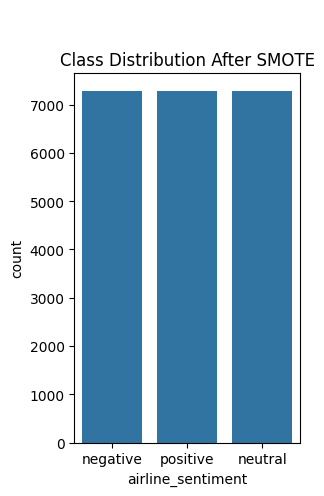

Classification Report After balncing:
              precision    recall  f1-score   support

    negative       0.89      0.82      0.86      1889
     neutral       0.54      0.60      0.57       580
    positive       0.64      0.75      0.69       459

    accuracy                           0.77      2928
   macro avg       0.69      0.73      0.71      2928
weighted avg       0.78      0.77      0.77      2928


Confusion Matrix:
[[1553  239   97]
 [ 136  350   94]
 [  53   60  346]]

Accuracy Score:
0.7681010928961749


In [10]:
# Check the distribution of sentiments after applying SMOTE
print('Distribution of sentiments after applying SMOTE\n', pd.Series(y_train_res).value_counts())

# After SMOTE
plt.subplot(1, 2, 2)
sns.countplot(x=y_train_res)
plt.title('\n\nClass Distribution After SMOTE')

plt.show()


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Train a Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train_res, y_train_res)

# Evaluate the model on the test set
y_pred = model.predict(X_test)

# Print classification report and confusion matrix
print("Classification Report After balncing:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))


In [11]:
# --- Step 11: Logistic Regression with Hyperparameter Tuning ---
param_grid = {
    'C': [0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'max_iter': [100, 200, 500]
}

grid_search = GridSearchCV(LogisticRegression(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_res, y_train_res)
best_lr_model = grid_search.best_estimator_

In [12]:
# --- Step 12: Evaluate Logistic Regression ---
y_pred = best_lr_model.predict(X_test)
print('Logistic Regression Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Logistic Regression Accuracy: 0.7284836065573771
              precision    recall  f1-score   support

    negative       0.86      0.80      0.83      1889
     neutral       0.48      0.53      0.50       580
    positive       0.59      0.69      0.63       459

    accuracy                           0.73      2928
   macro avg       0.64      0.67      0.66      2928
weighted avg       0.74      0.73      0.73      2928



In [13]:
# --- Step 13: Save the Best Model ---
joblib.dump(best_lr_model, 'logistic_regression_sentiment_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

In [62]:
# --- Step 14: Try Other Classifiers ---
# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_res, y_train_res)
y_pred_nb = nb_model.predict(X_test)
print('Naive Bayes Accuracy:', accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.7694672131147541
              precision    recall  f1-score   support

    negative       0.87      0.84      0.86      1889
     neutral       0.55      0.56      0.56       580
    positive       0.65      0.74      0.69       459

    accuracy                           0.77      2928
   macro avg       0.69      0.71      0.70      2928
weighted avg       0.78      0.77      0.77      2928



In [64]:
# SVM
# SVM
svm_model = SVC(kernel='linear')
svm_model.fit(X_train_res, y_train_res)
print('SVM Accuracy:', accuracy_score(y_test, svm_model.predict(X_test)))

# Classification Report for SVM
y_pred_svm = svm_model.predict(X_test)
print('\nSVM Classification Report:')
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.7735655737704918

SVM Classification Report:
              precision    recall  f1-score   support

    negative       0.88      0.83      0.86      1889
     neutral       0.55      0.59      0.57       580
    positive       0.67      0.75      0.71       459

    accuracy                           0.77      2928
   macro avg       0.70      0.73      0.71      2928
weighted avg       0.78      0.77      0.78      2928



In [16]:
# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_res, y_train_res)
print('Random Forest Accuracy:', accuracy_score(y_test, rf_model.predict(X_test)))
print(classification_report(y_test, rf_model.predict(X_test)))

Random Forest Accuracy: 0.7513661202185792
              precision    recall  f1-score   support

    negative       0.84      0.85      0.85      1889
     neutral       0.55      0.52      0.53       580
    positive       0.62      0.66      0.64       459

    accuracy                           0.75      2928
   macro avg       0.67      0.67      0.67      2928
weighted avg       0.75      0.75      0.75      2928



In [17]:
# --- Step 15: Cross-Validation for All Models ---

# Logistic Regression
lr_scores = cross_val_score(best_lr_model, X_train_res, y_train_res, cv=5, scoring='accuracy')
print('Logistic Regression CV Mean Accuracy:', lr_scores.mean())

# Naive Bayes
nb_scores = cross_val_score(nb_model, X_train_res, y_train_res, cv=5, scoring='accuracy')
print('Naive Bayes CV Mean Accuracy:', nb_scores.mean())

# SVM
svm_scores = cross_val_score(svm_model, X_train_res, y_train_res, cv=5, scoring='accuracy')
print('SVM CV Mean Accuracy:', svm_scores.mean())

# Random Forest
rf_scores = cross_val_score(rf_model, X_train_res, y_train_res, cv=5, scoring='accuracy')
print('Random Forest CV Mean Accuracy:', rf_scores.mean())

Logistic Regression CV Mean Accuracy: 0.8534811289001565
Naive Bayes CV Mean Accuracy: 0.7962243789073973
SVM CV Mean Accuracy: 0.8088921595721177
Random Forest CV Mean Accuracy: 0.871225024574563


In [18]:
# --- Step 16: Compare Model Performances ---
models = ['Logistic Regression', 'Naive Bayes', 'SVM', 'Random Forest']
accuracies = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, nb_model.predict(X_test)),
    accuracy_score(y_test, svm_model.predict(X_test)),
    accuracy_score(y_test, rf_model.predict(X_test))
]

cv_means = [
    lr_scores.mean(),
    nb_scores.mean(),
    svm_scores.mean(),
    rf_scores.mean()
]

performance_df = pd.DataFrame({
    'Model': models,
    'Test Accuracy': accuracies,
    'CV Mean Accuracy': cv_means
})

print("\n--- Model Performance Summary ---")
print(performance_df.sort_values(by='CV Mean Accuracy', ascending=False))


--- Model Performance Summary ---
                 Model  Test Accuracy  CV Mean Accuracy
3        Random Forest       0.751366          0.871225
0  Logistic Regression       0.728484          0.853481
2                  SVM       0.773566          0.808892
1          Naive Bayes       0.769467          0.796224


In [19]:
# --- Step 17: Save Other Models (Optional) ---
joblib.dump(nb_model, 'naive_bayes_model.pkl')

['naive_bayes_model.pkl']

In [20]:
joblib.dump(svm_model, 'svm_model.pkl')

['svm_model.pkl']

In [21]:
joblib.dump(rf_model, 'random_forest_model.pkl')

['random_forest_model.pkl']

In [22]:
# --- Step 18: Make Predictions on New Data (Example) ---
def predict_sentiment(new_text):
    cleaned = clean_text(new_text)
    tokens = tokenize(cleaned)
    tokens = remove_stopwords(tokens)
    tokens = lemmatize_and_correct(tokens)
    final_text = ' '.join(tokens)
    vec = tfidf.transform([final_text]).toarray()
    prediction = best_lr_model.predict(vec)[0]
    return prediction

In [23]:
# Example usage:
example = "I am so disappointed with the delay in my flight."
print("Predicted Sentiment:", predict_sentiment(example))

Predicted Sentiment: negative


# Analyze which airline receives the most negative/positive feedback

In [25]:
# --- Step 1: Analyze the Sentiment by Airline ---

# Filter positive and negative sentiment tweets
positive_tweets = df[df['airline_sentiment'] == 'positive']
negative_tweets = df[df['airline_sentiment'] == 'negative']

# Count the number of positive and negative sentiment tweets for each airline
positive_sentiment_by_airline = positive_tweets['airline'].value_counts()
negative_sentiment_by_airline = negative_tweets['airline'].value_counts()


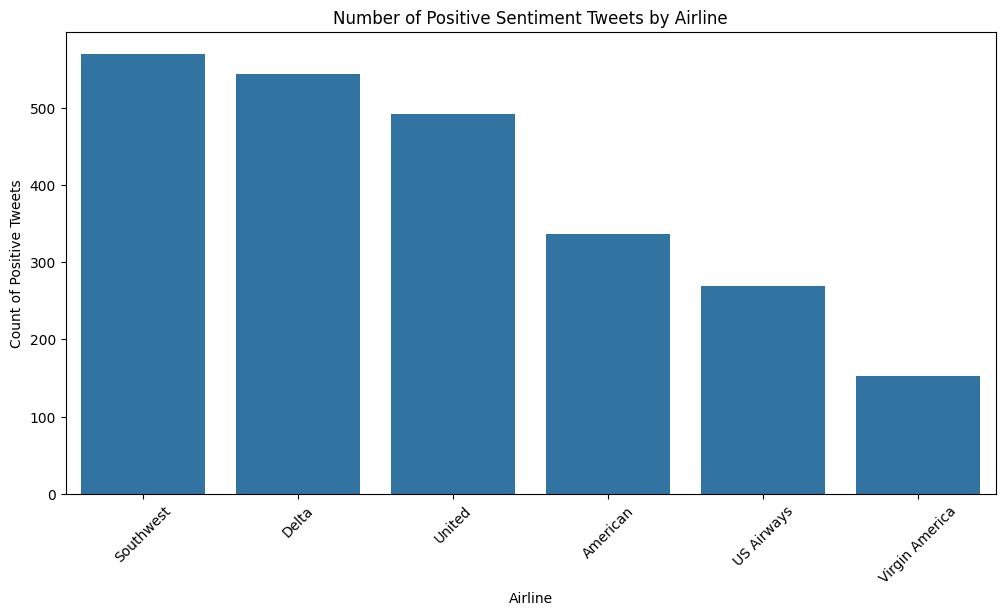

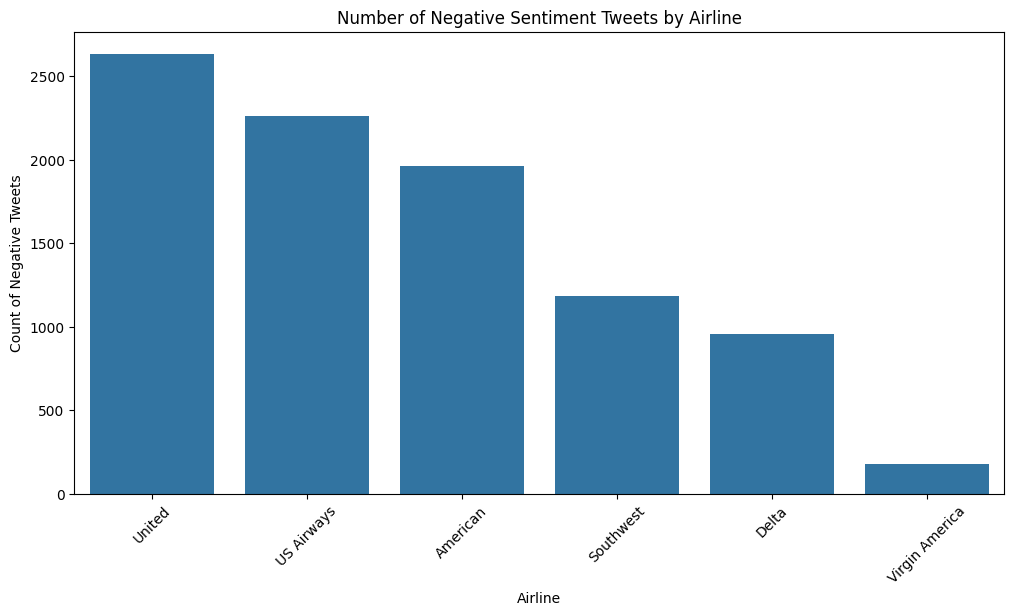

In [26]:
# --- Step 2: Visualize the Results ---

# Plot the number of positive sentiment tweets by airline
plt.figure(figsize=(12,6))
sns.barplot(x=positive_sentiment_by_airline.index, y=positive_sentiment_by_airline.values)
plt.title('Number of Positive Sentiment Tweets by Airline')
plt.xlabel('Airline')
plt.ylabel('Count of Positive Tweets')
plt.xticks(rotation=45)
plt.show()

# Plot the number of negative sentiment tweets by airline
plt.figure(figsize=(12,6))
sns.barplot(x=negative_sentiment_by_airline.index, y=negative_sentiment_by_airline.values)
plt.title('Number of Negative Sentiment Tweets by Airline')
plt.xlabel('Airline')
plt.ylabel('Count of Negative Tweets')
plt.xticks(rotation=45)
plt.show()


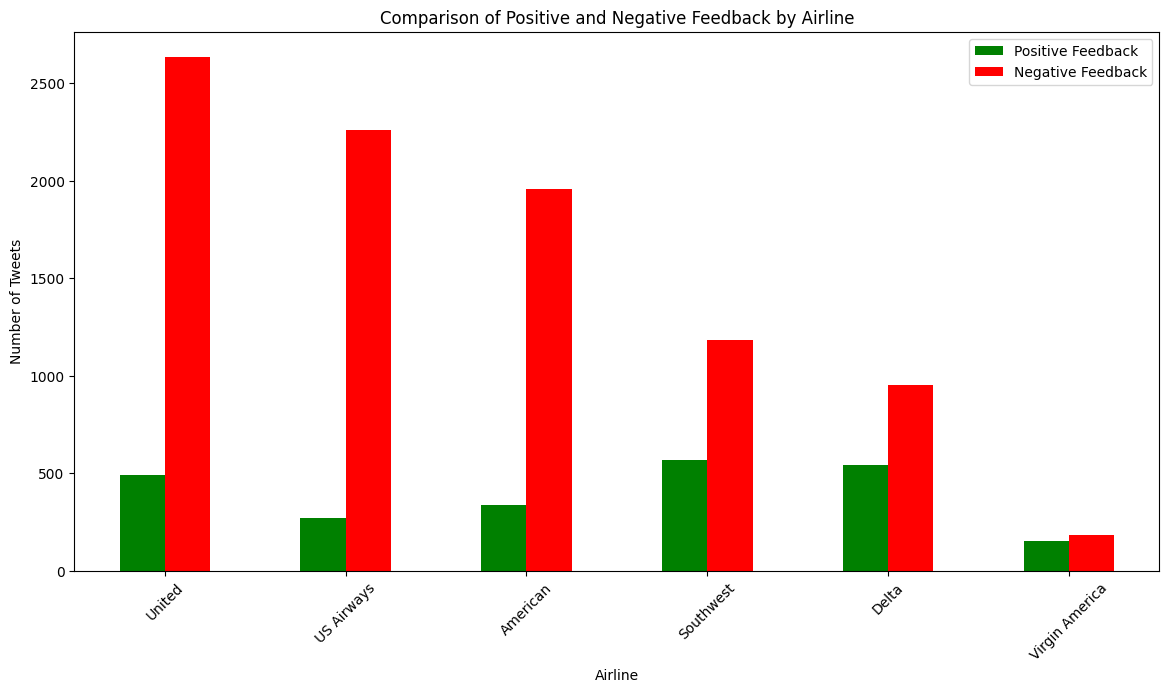

In [27]:
# --- Step 3: Compare Positive and Negative Feedback ---

# Merge both positive and negative counts into a single dataframe for comparison
feedback_comparison = pd.DataFrame({
    'Positive Feedback': positive_sentiment_by_airline,
    'Negative Feedback': negative_sentiment_by_airline
}).fillna(0)  # Fill missing values with 0 for airlines with no feedback

# Plot the comparison of positive and negative feedback for each airline
feedback_comparison = feedback_comparison.sort_values(by='Negative Feedback', ascending=False)
feedback_comparison.plot(kind='bar', stacked=False, figsize=(14,7), color=['green', 'red'])
plt.title('Comparison of Positive and Negative Feedback by Airline')
plt.xlabel('Airline')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=45)
plt.show()

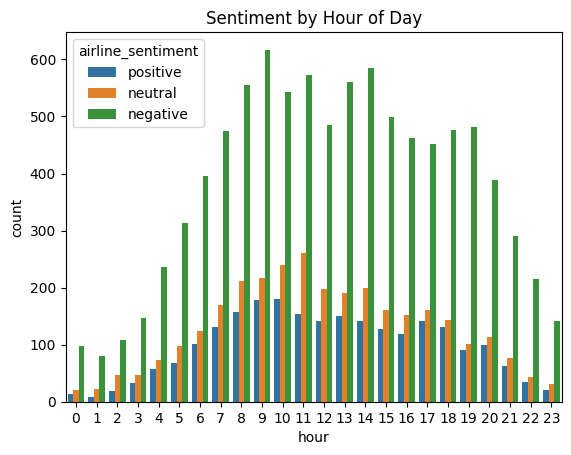

In [28]:
# Predicting Sentiment for Non-Textual Data

df['hour'] = df['tweet_created'].dt.hour
sns.countplot(x='hour', hue='airline_sentiment', data=df)
plt.title('Sentiment by Hour of Day')
plt.show()


# Time Series Analysis

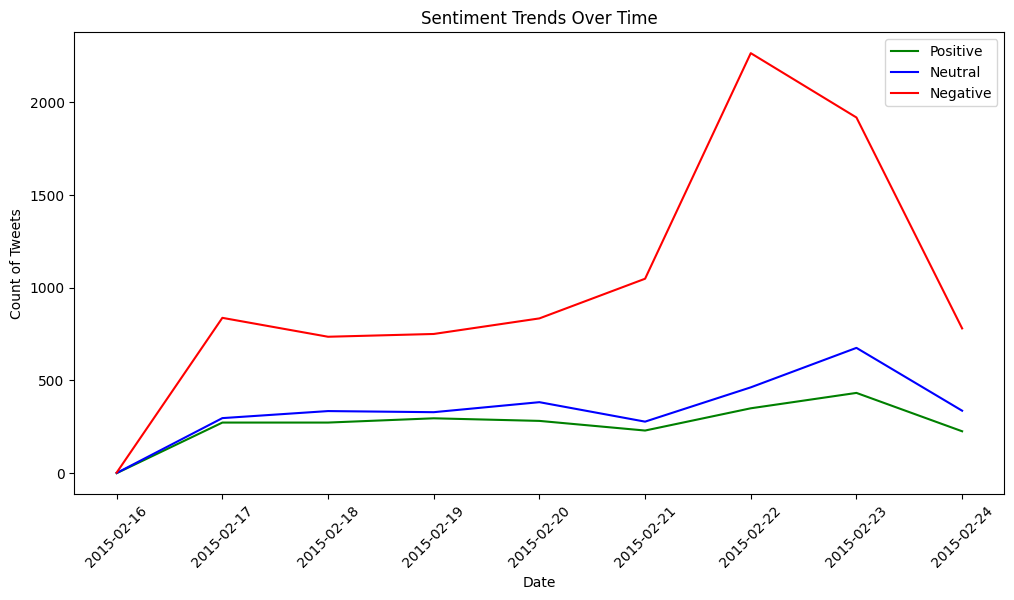

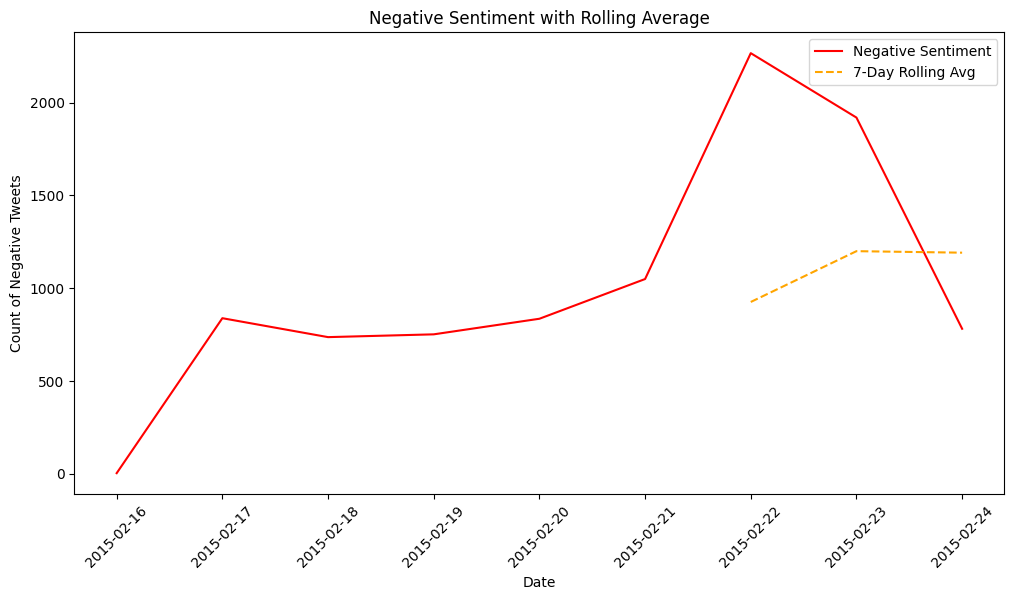

In [30]:
# --- Step 1: Prepare Data ---
# Convert 'tweet_created' to datetime if it's not already
df['tweet_created'] = pd.to_datetime(df['tweet_created'])

# Extract day and hour from 'tweet_created' to use for analysis
df['date'] = df['tweet_created'].dt.date
df['hour'] = df['tweet_created'].dt.hour

# --- Step 2: Group Data by Time and Sentiment ---
# Group by date and sentiment to get the count of each sentiment per day
sentiment_by_day = df.groupby(['date', 'airline_sentiment']).size().unstack(fill_value=0)

# --- Step 3: Visualize Sentiment Trends Over Time ---
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sentiment_by_day['positive'].plot(label='Positive', color='green')
sentiment_by_day['neutral'].plot(label='Neutral', color='blue')
sentiment_by_day['negative'].plot(label='Negative', color='red')
plt.title('Sentiment Trends Over Time')
plt.xlabel('Date')
plt.ylabel('Count of Tweets')
plt.legend()
plt.xticks(rotation=45)
plt.show()

# --- Step 4: Detect Spikes in Negative Sentiment ---
# You can detect spikes by comparing the negative sentiment counts against a moving average
# Calculate a rolling window of 7 days to see trends better (or tune the window as needed)
sentiment_by_day['negative_rolling'] = sentiment_by_day['negative'].rolling(window=7).mean()

# Plot negative sentiment vs rolling average
plt.figure(figsize=(12, 6))
sentiment_by_day['negative'].plot(label='Negative Sentiment', color='red')
sentiment_by_day['negative_rolling'].plot(label='7-Day Rolling Avg', color='orange', linestyle='--')
plt.title('Negative Sentiment with Rolling Average')
plt.xlabel('Date')
plt.ylabel('Count of Negative Tweets')
plt.legend()
plt.xticks(rotation=45)
plt.show()

